In [84]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import logging
import seaborn as sns

from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

In [85]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger()
logger.setLevel(logging.WARNING)  # Set default logging level to WARNING

In [86]:
def kcc_consensus(partitions, K, weights=None):
    """
    K-means-based consensus clustering (KCC)
    
    Parameters:
    ----------
    partitions : list of array-like
        Each element is a base partition with shape=(n_samples,), and labels are integers.
    K : int
        Number of clusters in the final consensus partition.
    weights : list of float, optional
        Weights for each base partition; default is 1.0.
        
    Returns:
    -------
    final_labels : ndarray of shape (n_samples,)
        Consensus clustering labels.
    """
    if not partitions:
        raise ValueError("Partitions list is empty.")
    
    n_samples = len(partitions[0])
    # Validate that all partitions have the same length
    for i, part in enumerate(partitions):
        if len(part) != n_samples:
            raise ValueError(f"Partition {i} has length {len(part)}, expected {n_samples}.")
    
    all_cluster_vectors = []
    all_weights = []

    # Iterate through each base partition
    for i, part in enumerate(partitions):
        unique_labels = np.unique(part)
        w = weights[i] if weights is not None else 1.0
        
        # Build a one-hot vector for each cluster in the current partition
        for label in unique_labels:
            vec = (part == label).astype(int)  # shape: (n_samples,)
            all_cluster_vectors.append(vec)
            all_weights.append(w)
    
    # Build the "cluster-object" matrix: each row is one cluster from a base partition
    X = np.array(all_cluster_vectors)  # shape: (total_clusters, n_samples)
    sample_weight = np.array(all_weights)

    # Run weighted K-means on cluster objects (cluster into K groups)
    kmeans = KMeans(n_clusters=K, random_state=0, n_init=20)
    consensus_labels_on_clusters = kmeans.fit_predict(X, sample_weight=sample_weight)

    # Voting: assign a final label to each original sample (neuron)
    final_labels = np.zeros(n_samples, dtype=int)
    cluster_obj_index = 0  # Global index of the current cluster object

    for j in range(n_samples):
        votes = []
        current_index = 0
        for part in partitions:
            label_in_part = part[j]
            unique_labels = np.unique(part)
            # Find the position of this sample's cluster object in the global list for this partition
            local_cluster_idx = np.where(unique_labels == label_in_part)[0][0]
            global_cluster_obj_idx = current_index + local_cluster_idx
            votes.append(consensus_labels_on_clusters[global_cluster_obj_idx])
            current_index += len(unique_labels)
        
        # Majority vote (tie handling: choose the smallest label)
        vote_counts = np.bincount(votes)
        final_labels[j] = np.argmax(vote_counts)

    return final_labels

In [87]:
from scipy.spatial.distance import cdist
def sts_pair_fast(spike_times_i, spike_times_j, dt):
    if len(spike_times_i) == 0 or len(spike_times_j) == 0:
        return 0.0
    
    ti = np.array(spike_times_i).reshape(-1, 1)
    tj = np.array(spike_times_j).reshape(-1, 1)
    
    # Compute all pairwise |ti - tj|
    dists = cdist(ti, tj, metric='cityblock')  # L1 distance = |ti - tj|
    
    # Check if any distance <= dt for each spike
    matched_i = np.any(dists <= dt, axis=1)  # shape: (len(ti),)
    matched_j = np.any(dists <= dt, axis=0)  # shape: (len(tj),)
    
    count_i = matched_i.sum()
    count_j = matched_j.sum()
    
    sts = (count_i + count_j) / (len(ti) + len(tj))
    return np.clip(sts, 0, 1)

def compute_sts_matrix(spike_trains, dt):
    """
    spike_trains: list of lists, e.g., [train1, train2, ..., trainN]
    dt: time window (same units as spike times)
    Returns: N x N STS matrix (symmetric, diagonal = 1)
    """
    n = len(spike_trains)
    sts_mat = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i, n):
            if i == j:
                sts_mat[i, j] = 1.0
            else:
                sts_val = sts_pair_fast(spike_trains[i], spike_trains[j], dt)
                sts_mat[i, j] = sts_val
                sts_mat[j, i] = sts_val
    
    return sts_mat

def mean_sts(sts_mat):
    """Return scalar: average STS over all unique pairs"""
    n = sts_mat.shape[0]
    return sts_mat[np.triu_indices(n, k=0)].mean()

Processing CSDS0126 - pre


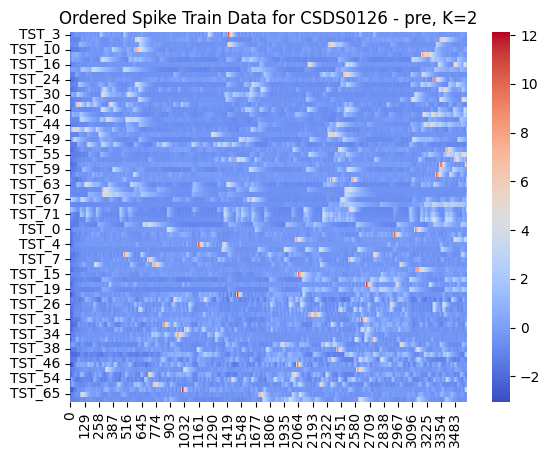

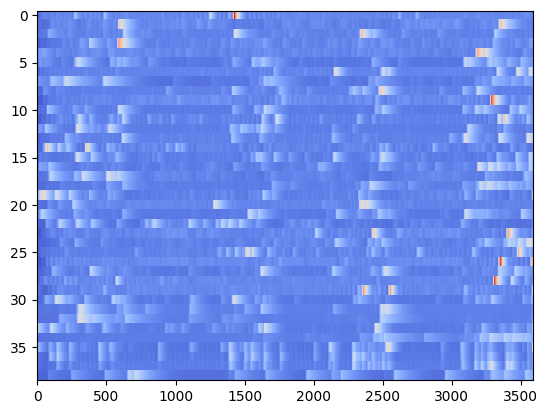

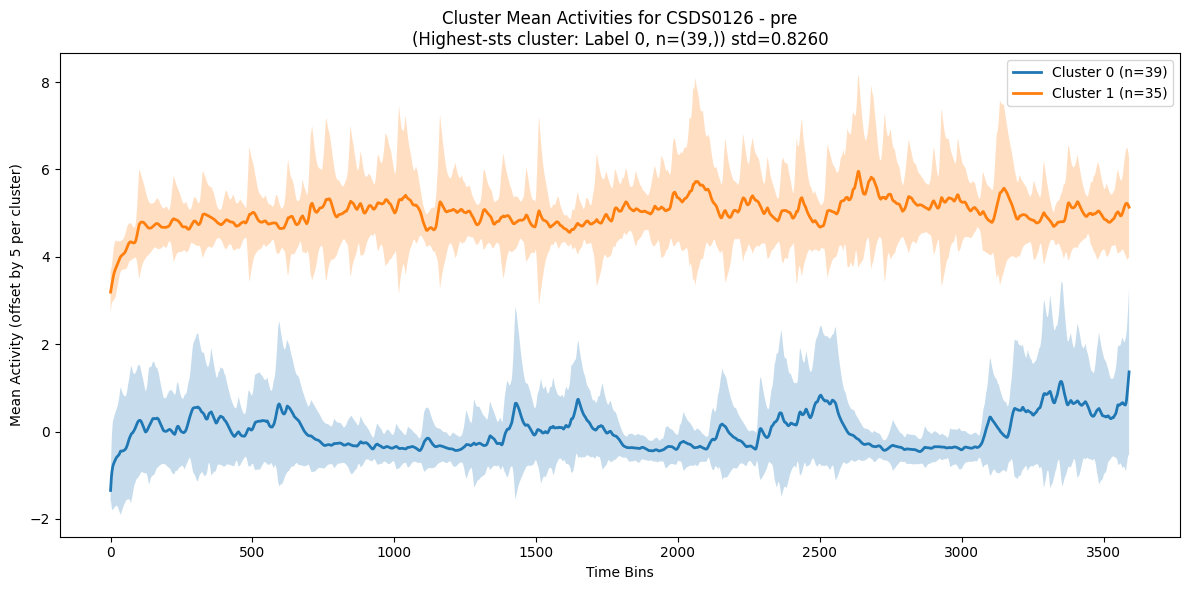

Processing LH0167 - pre


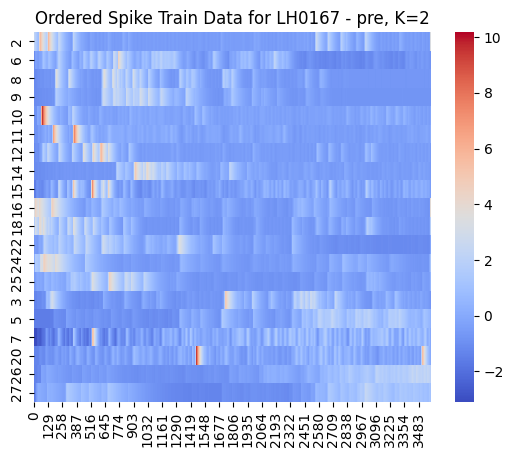

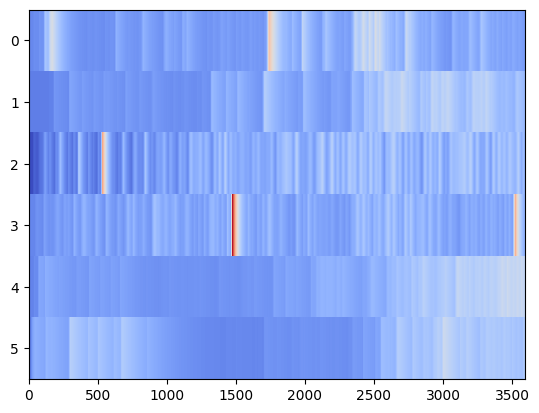

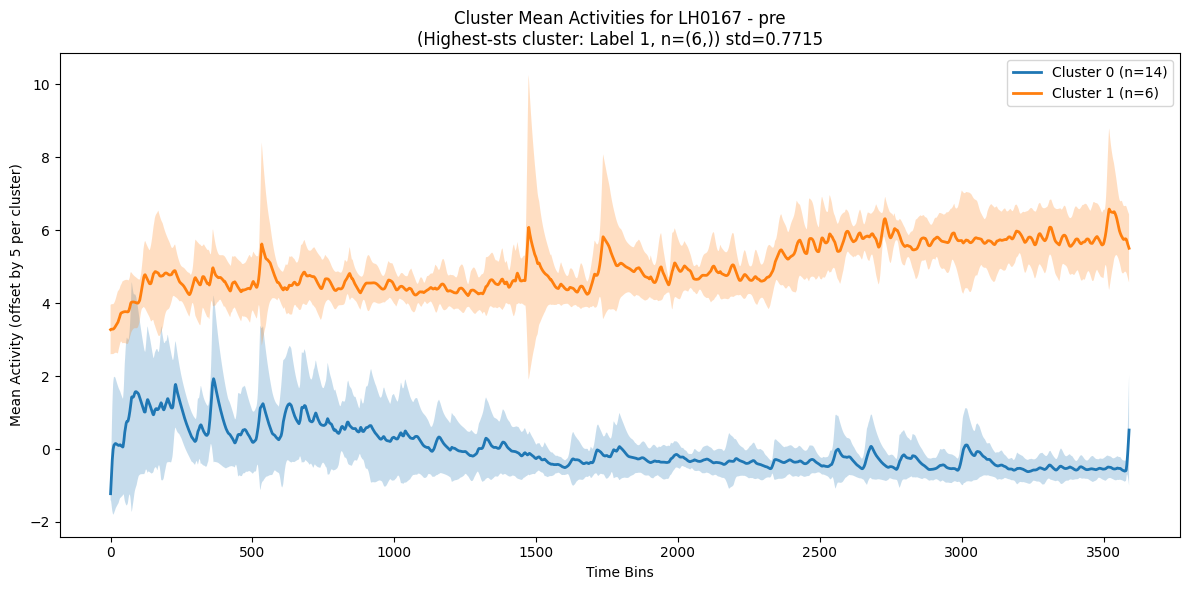

Processing CSDS5776 - pre


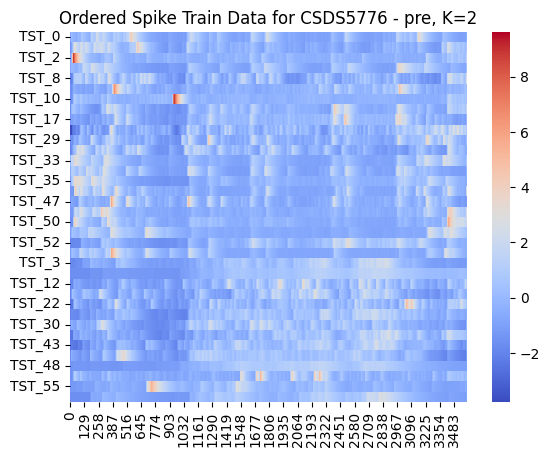

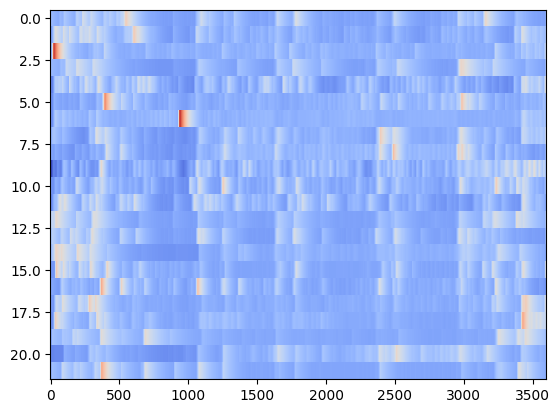

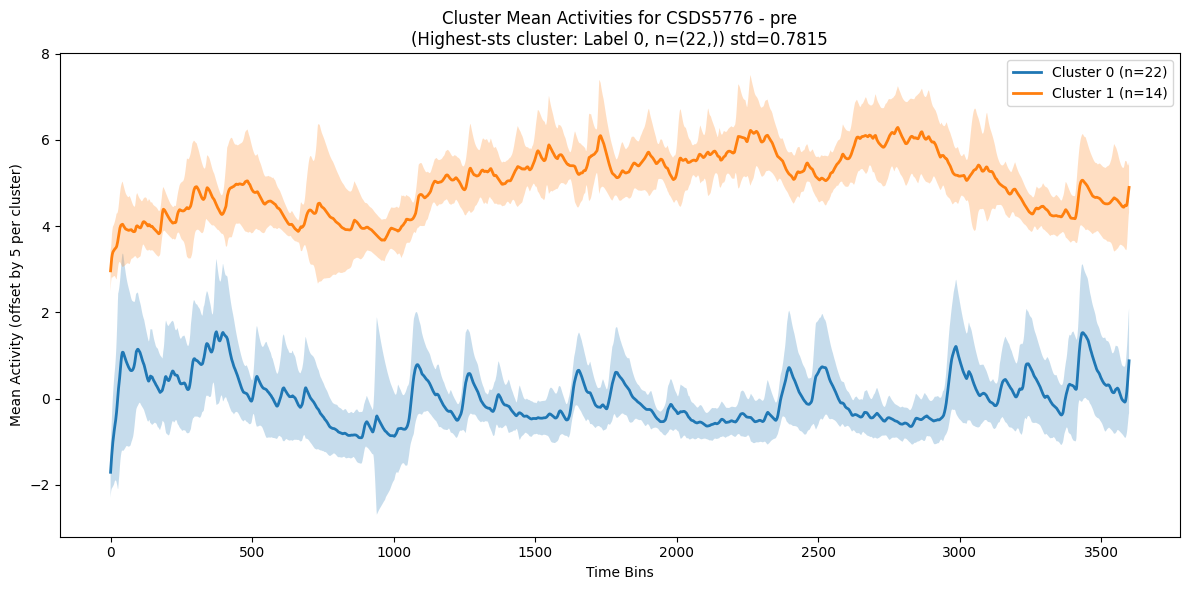

Processing CSDS5797 - pre


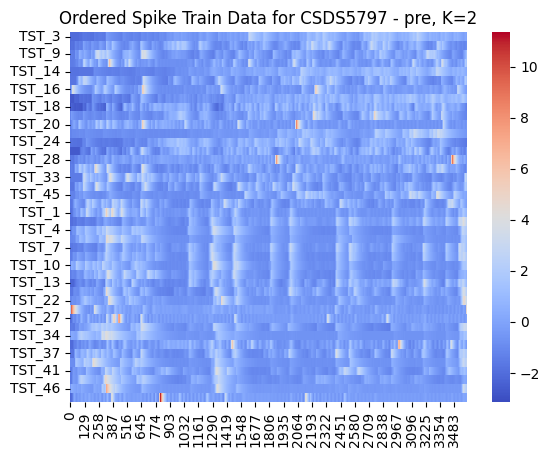

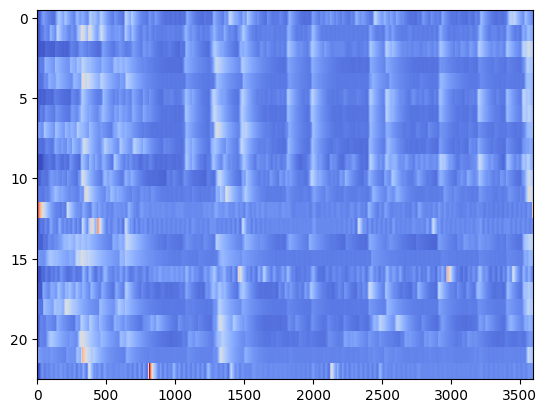

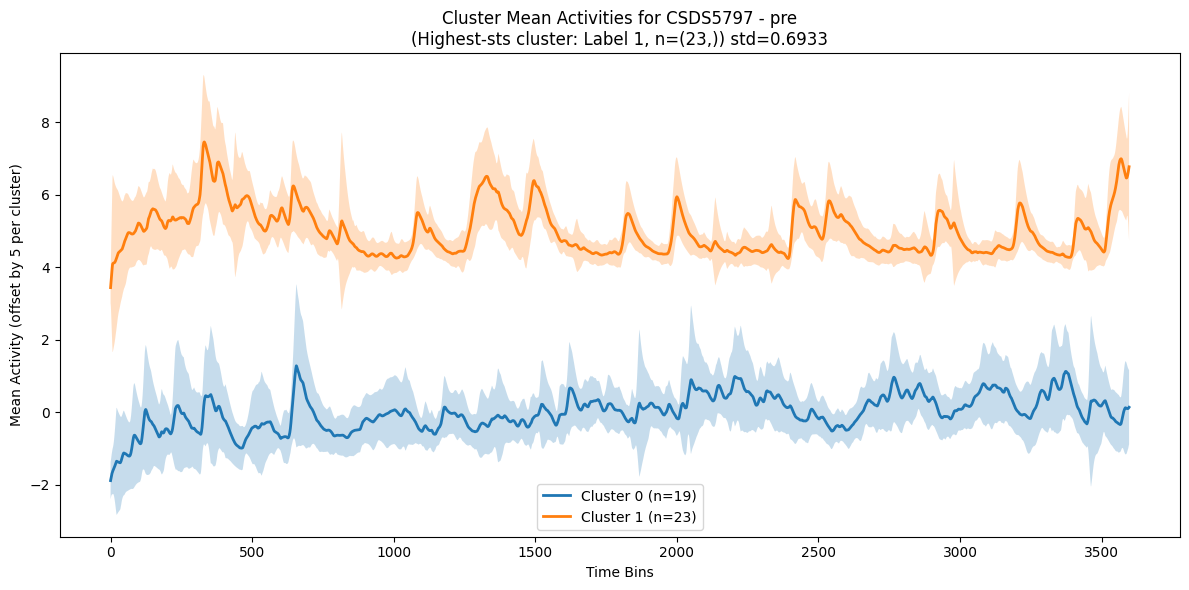

Processing CSDSQ26 - pre


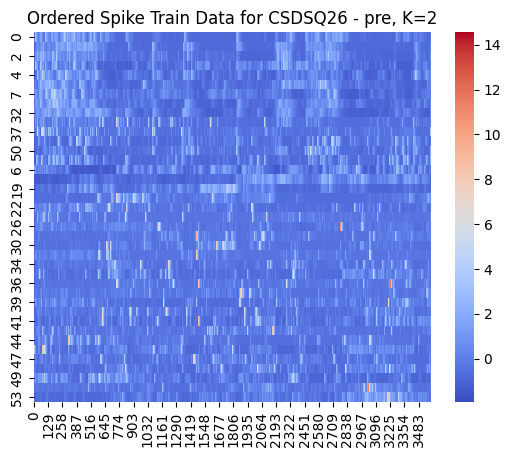

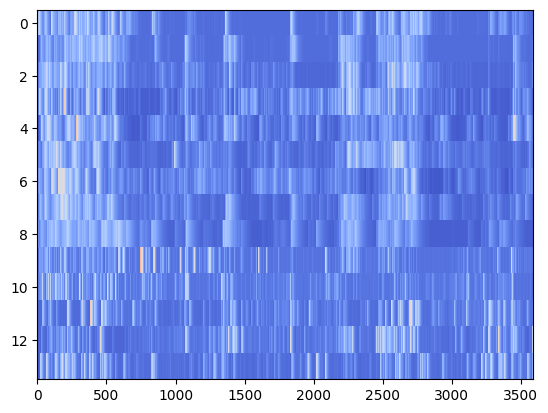

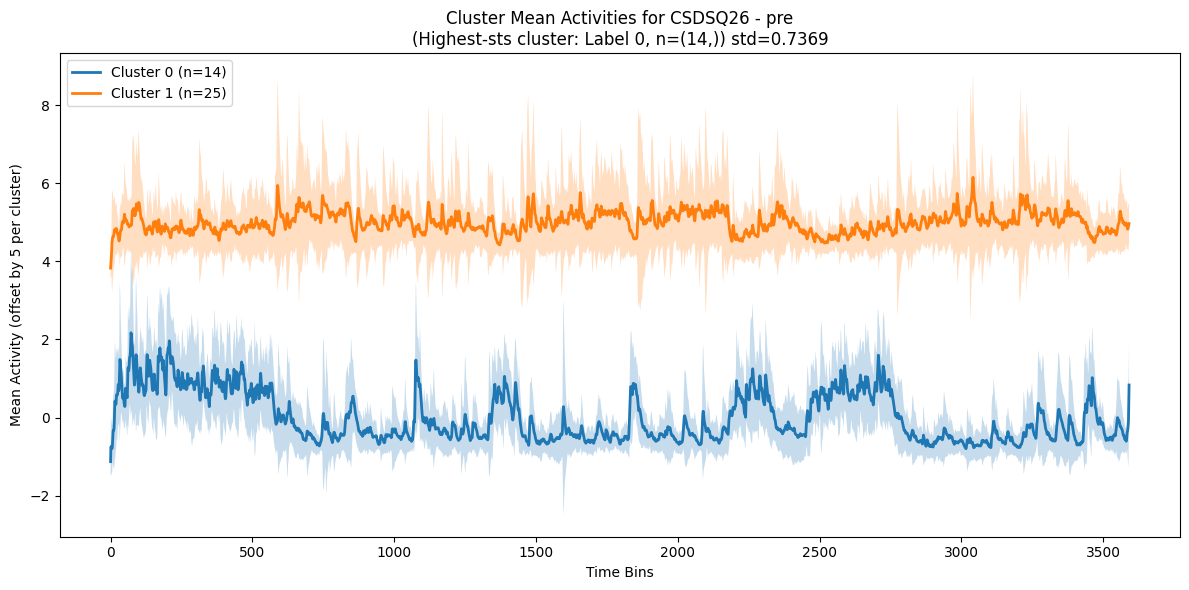

Processing LHQ30 - pre


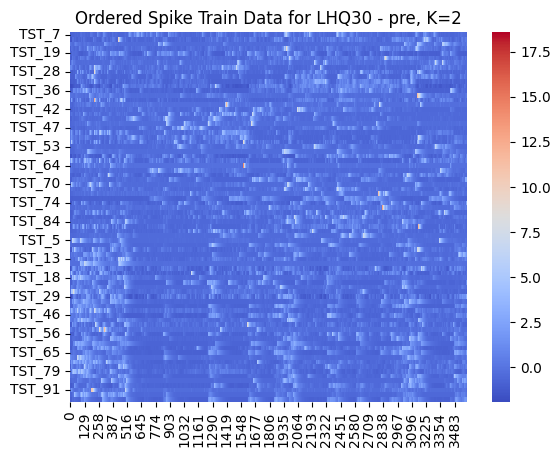

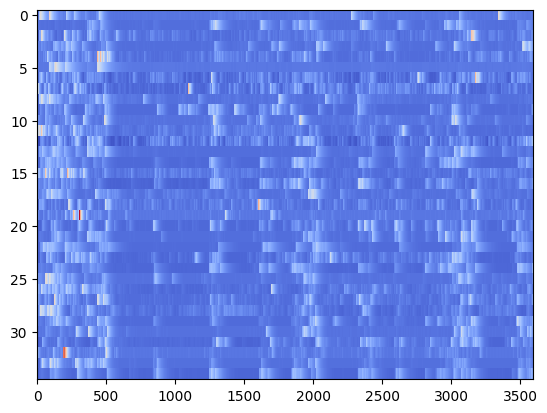

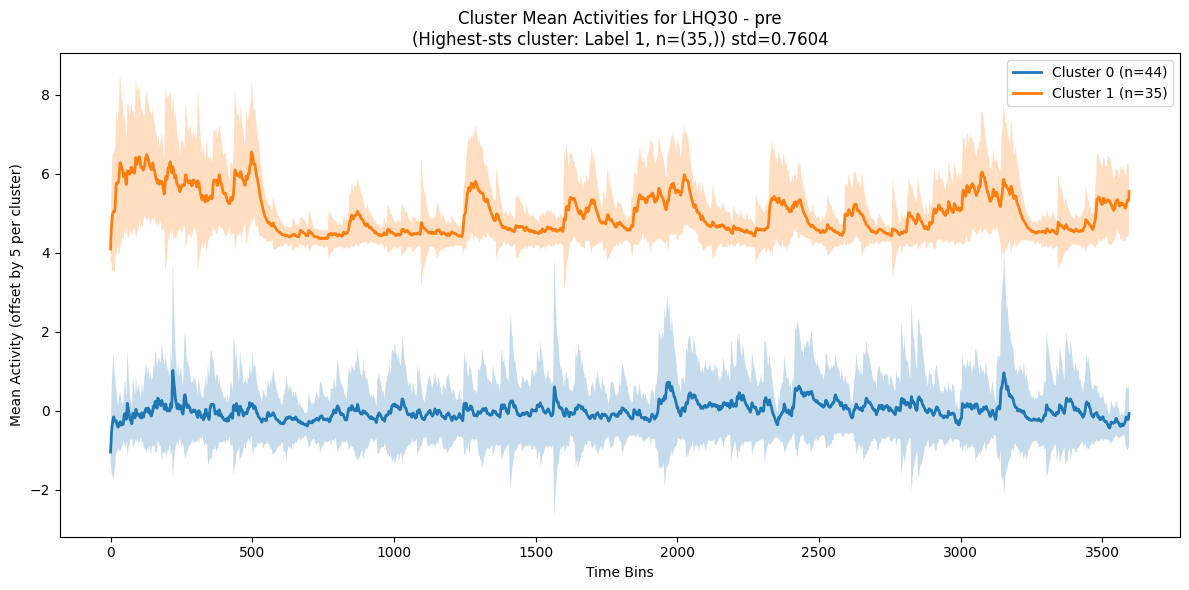

Processing LHQ50 - pre


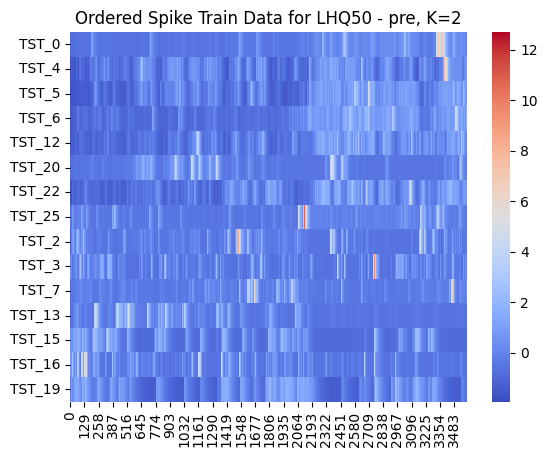

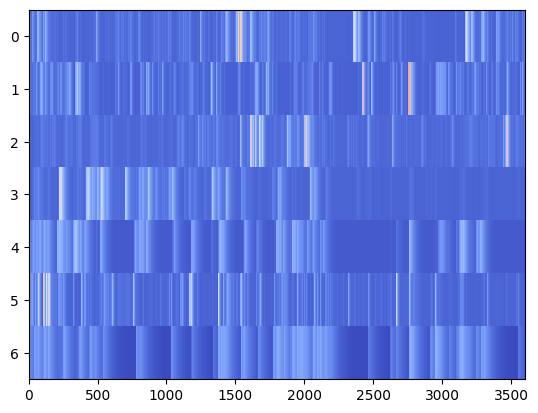

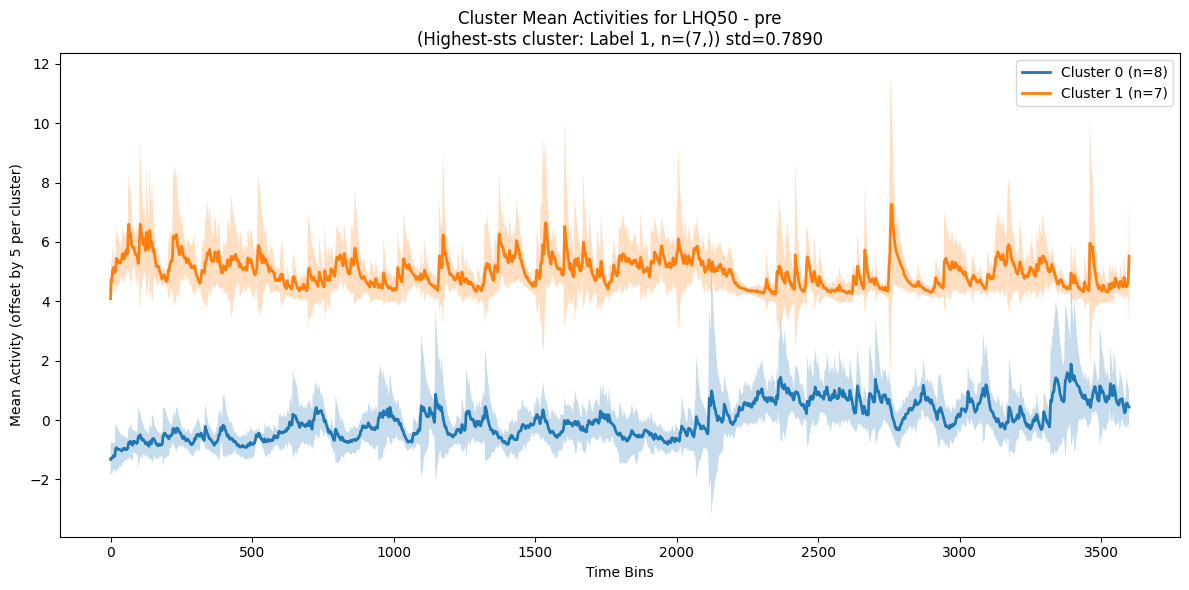

Processing CSDS0126 - post


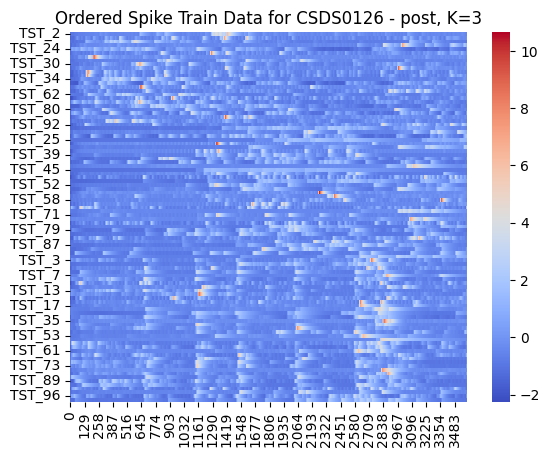

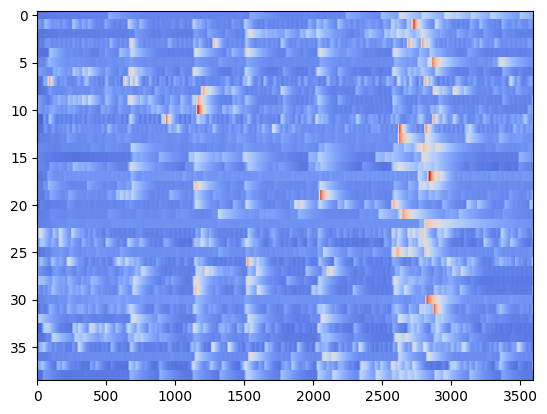

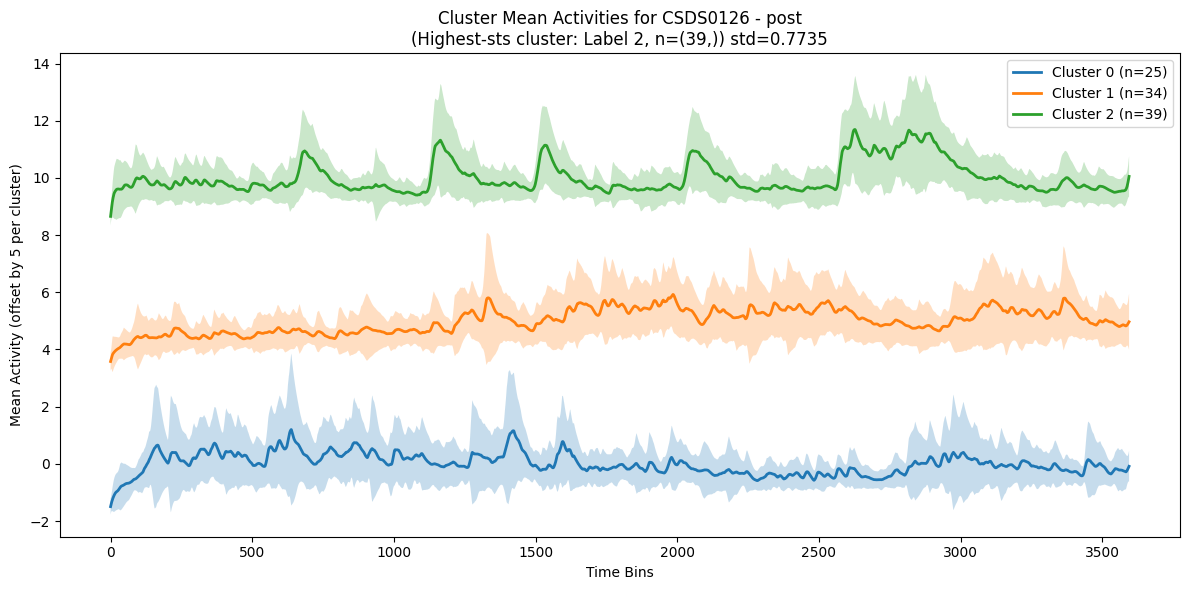

Processing LH0167 - post


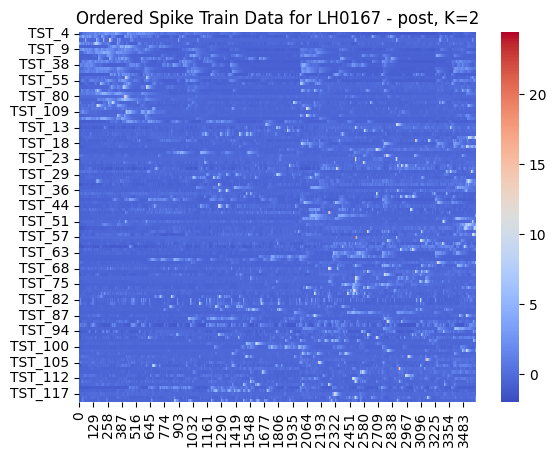

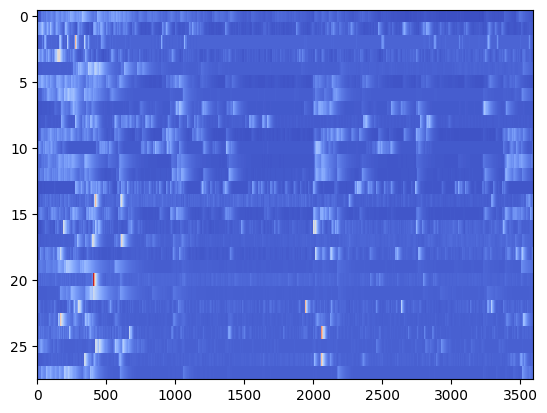

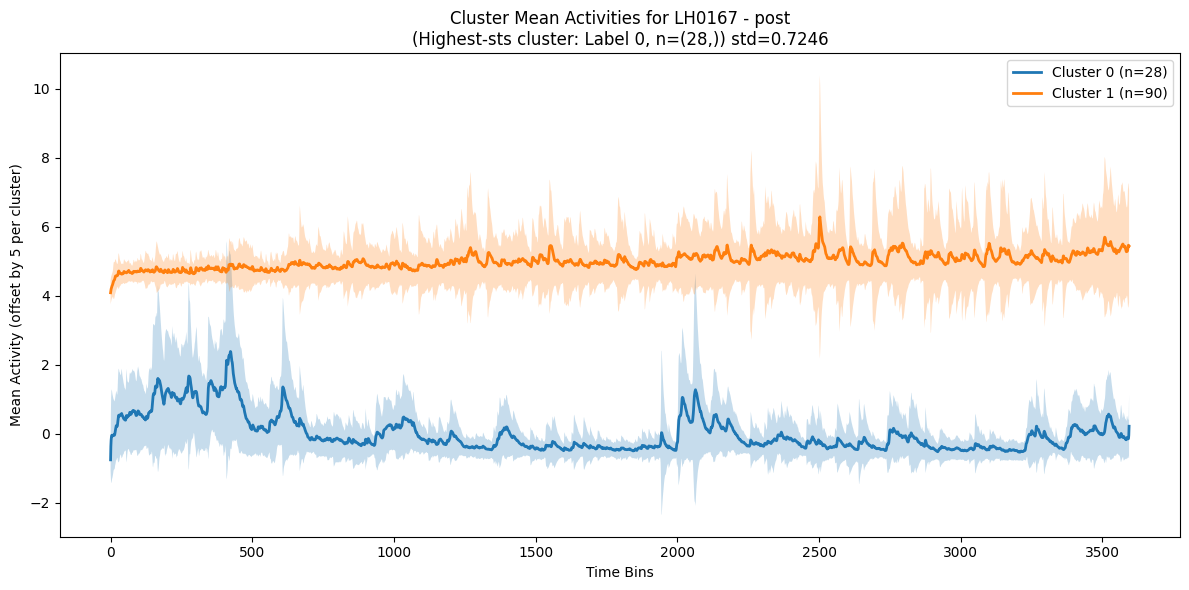

Processing CSDS5776 - post


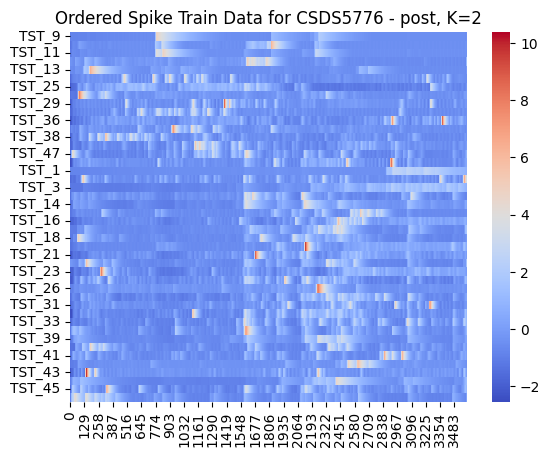

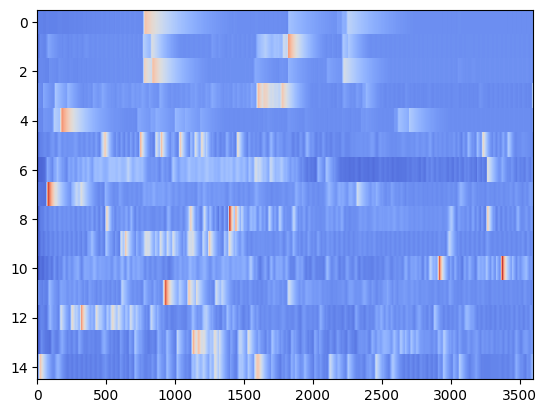

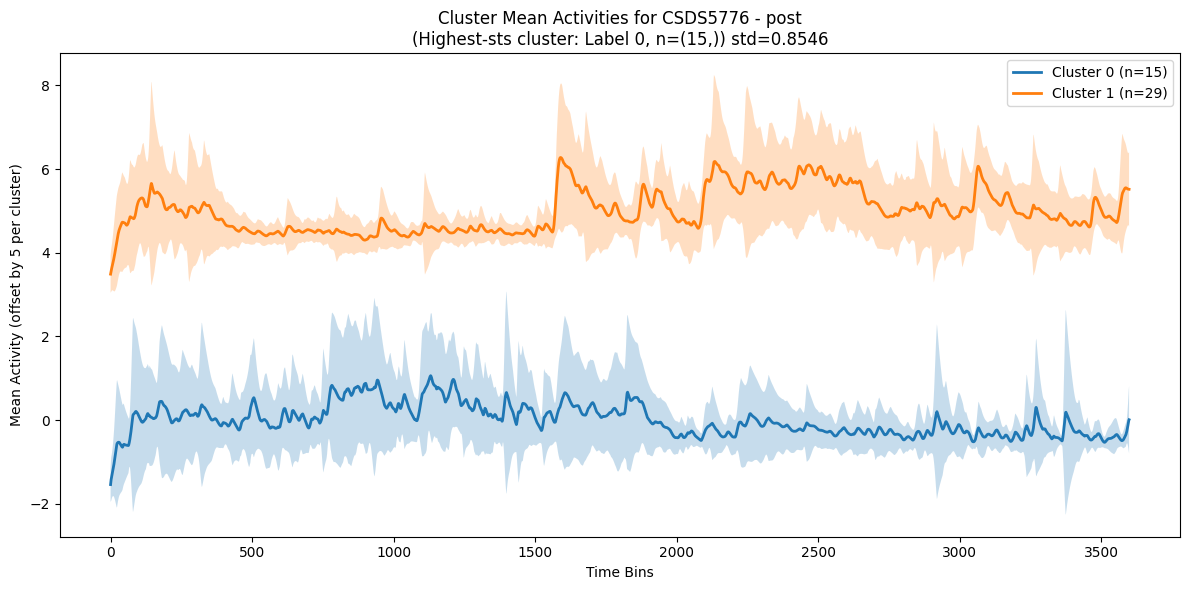

Processing CSDS5797 - post


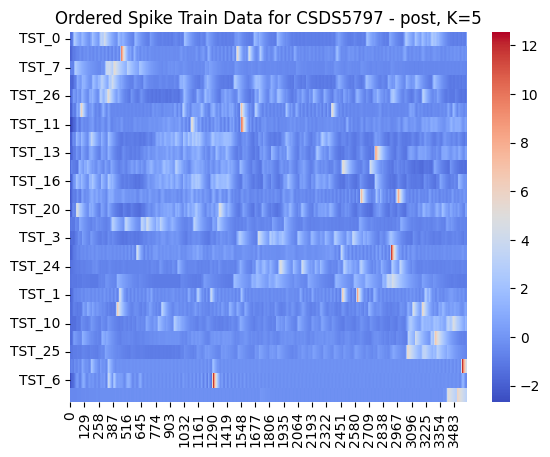

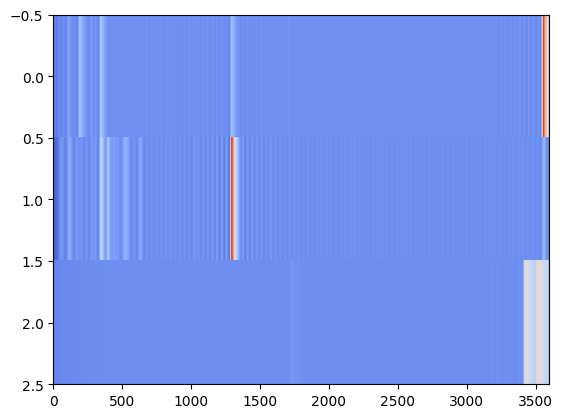

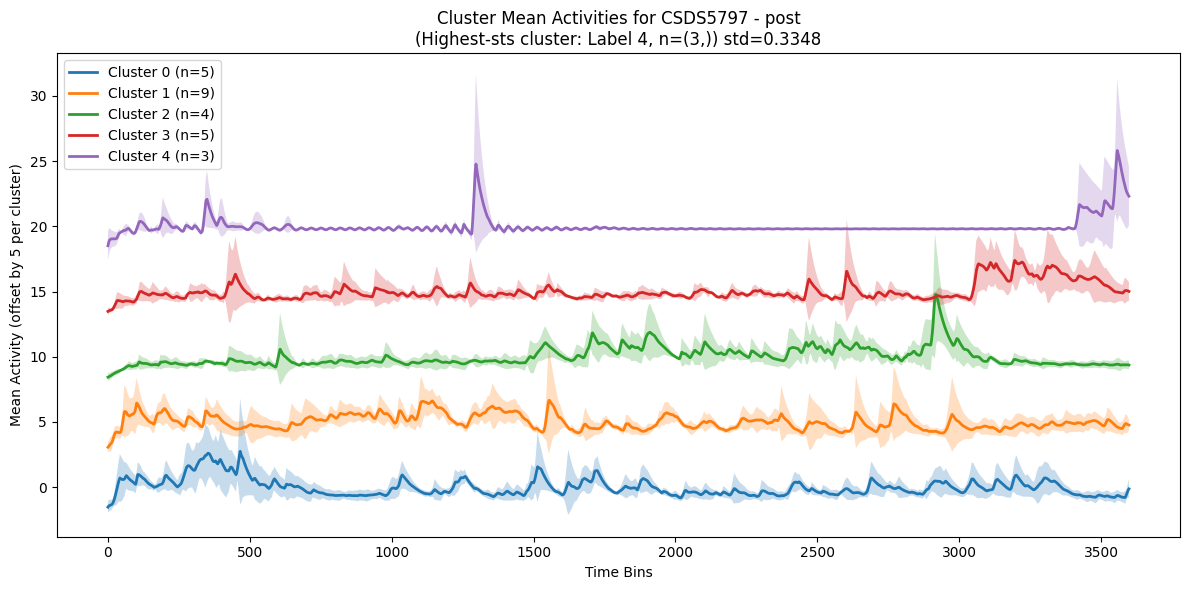

Processing CSDSQ26 - post


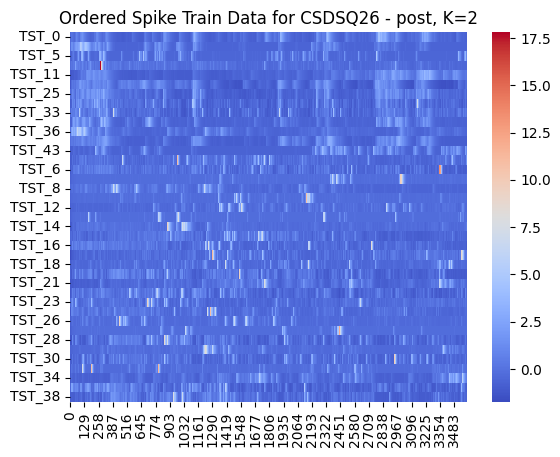

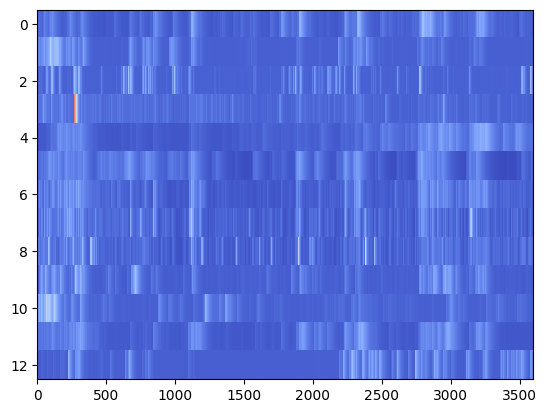

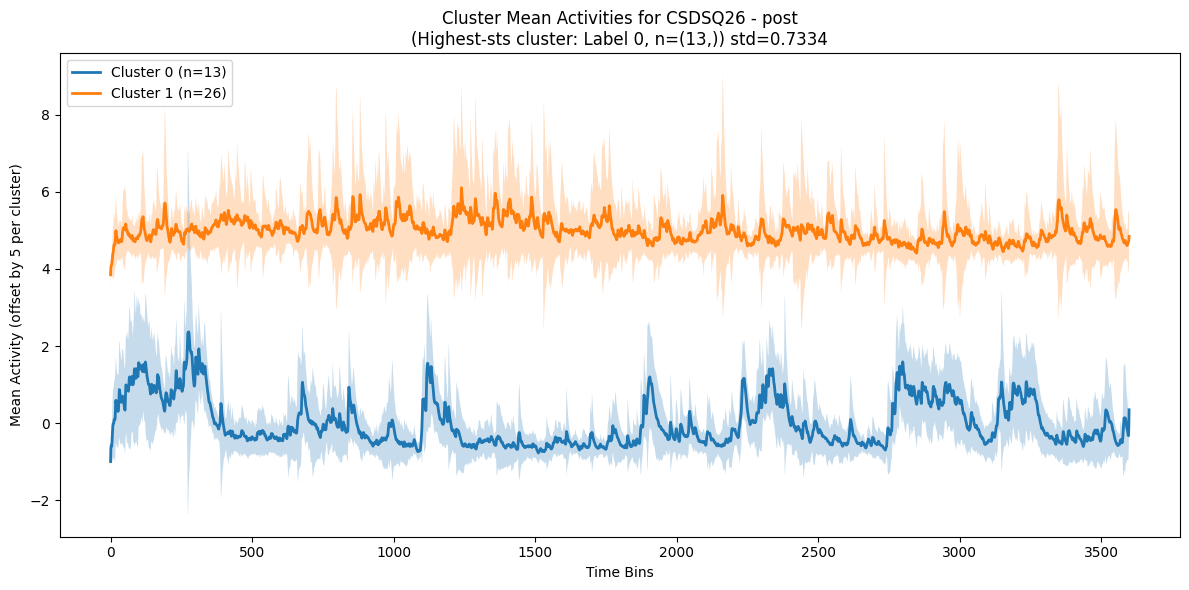

Processing LHQ30 - post


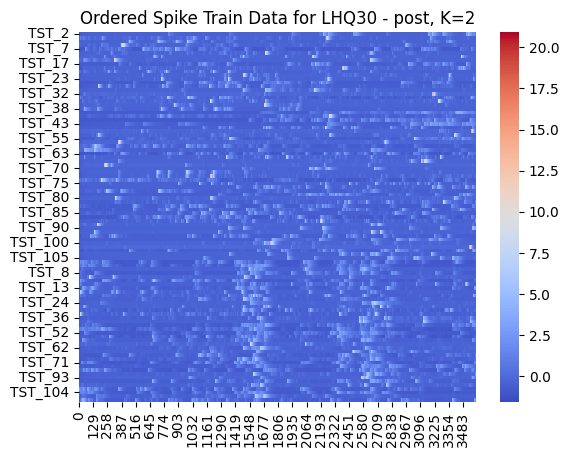

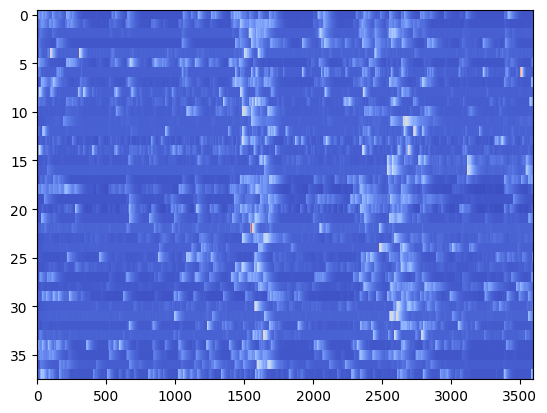

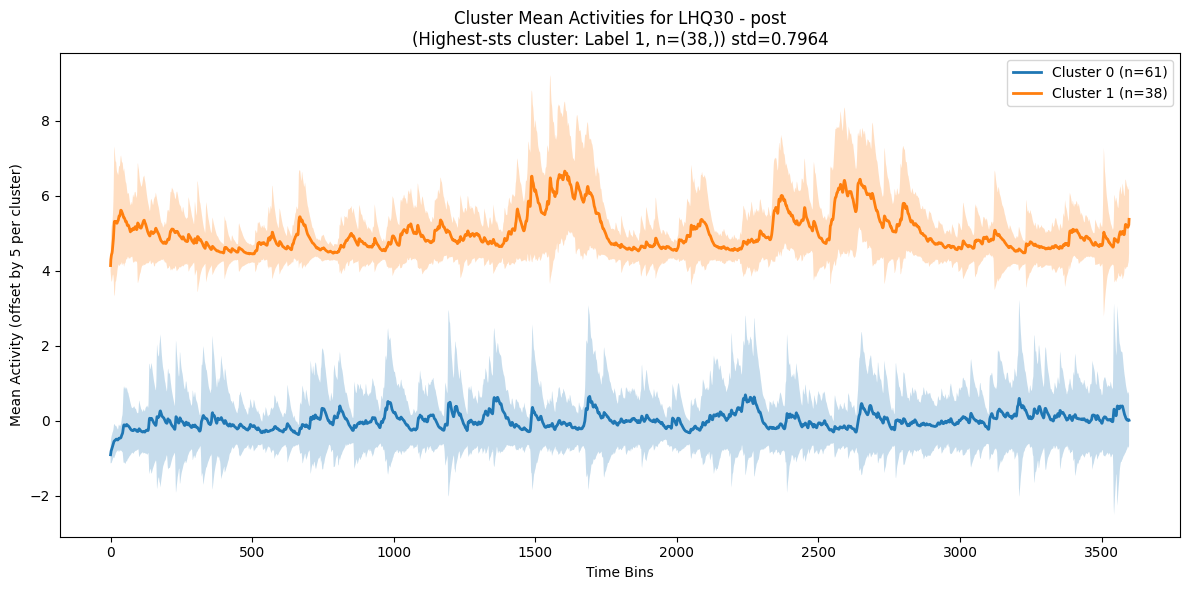

Processing LHQ50 - post


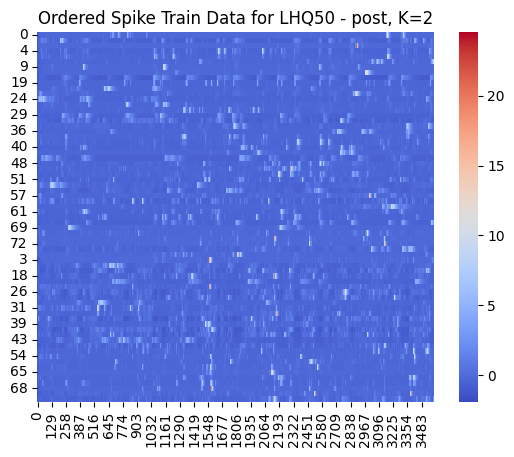

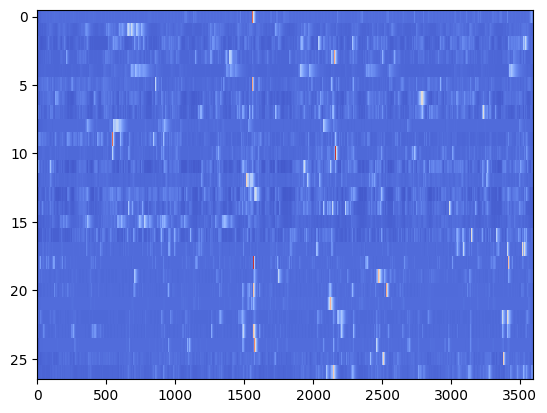

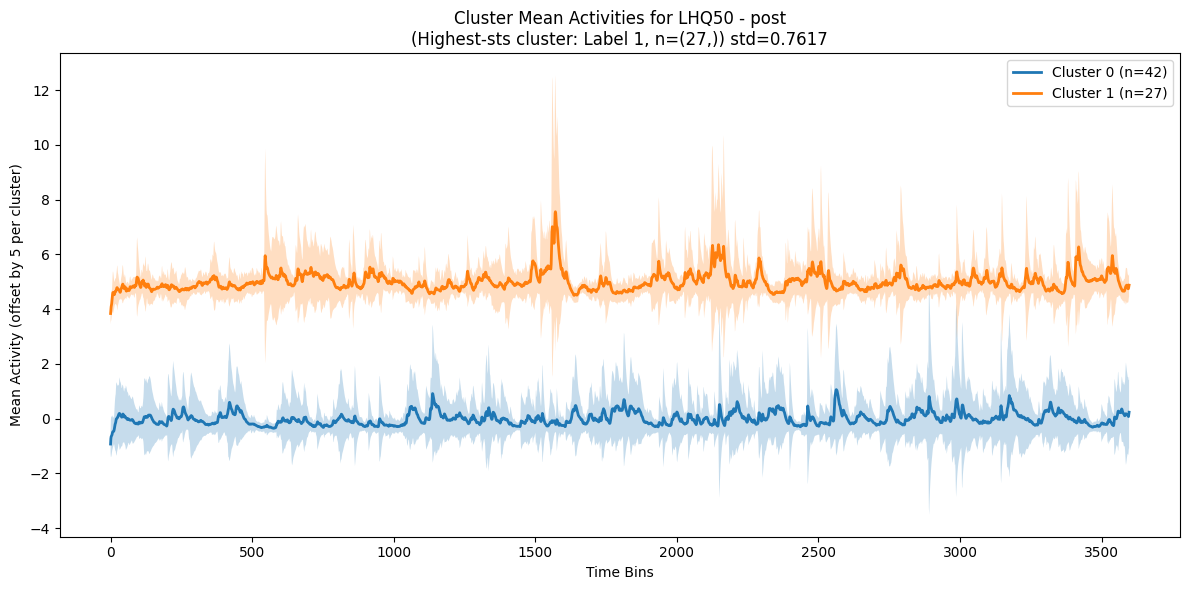

File not found: G:\XJN_M2project\signal_data\test2\rescue\CSDS0126\signal_save\CSDS0126_rescue_all_cell_table_TST.csv, skipping CSDS0126
File not found: G:\XJN_M2project\signal_data\test2\rescue\LH0167\signal_save\LH0167_rescue_all_cell_table_TST.csv, skipping LH0167
Processing CSDS5776 - rescue


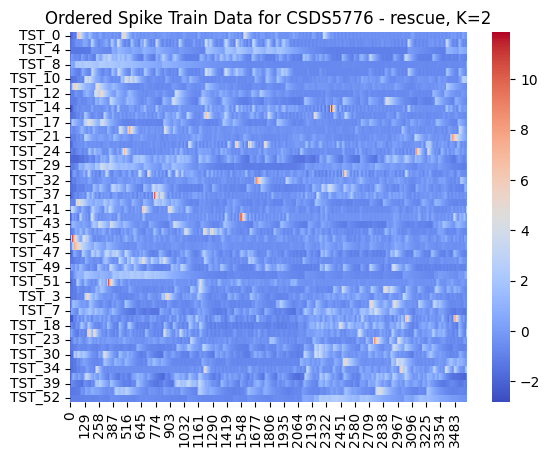

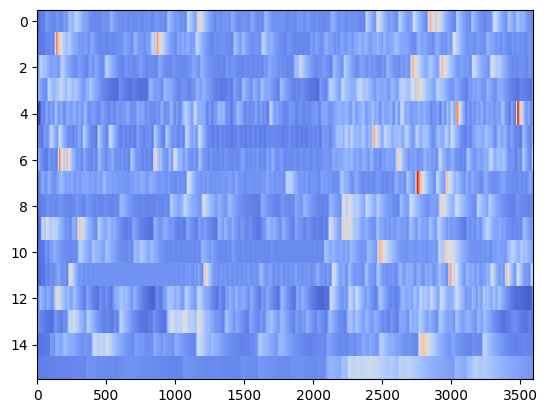

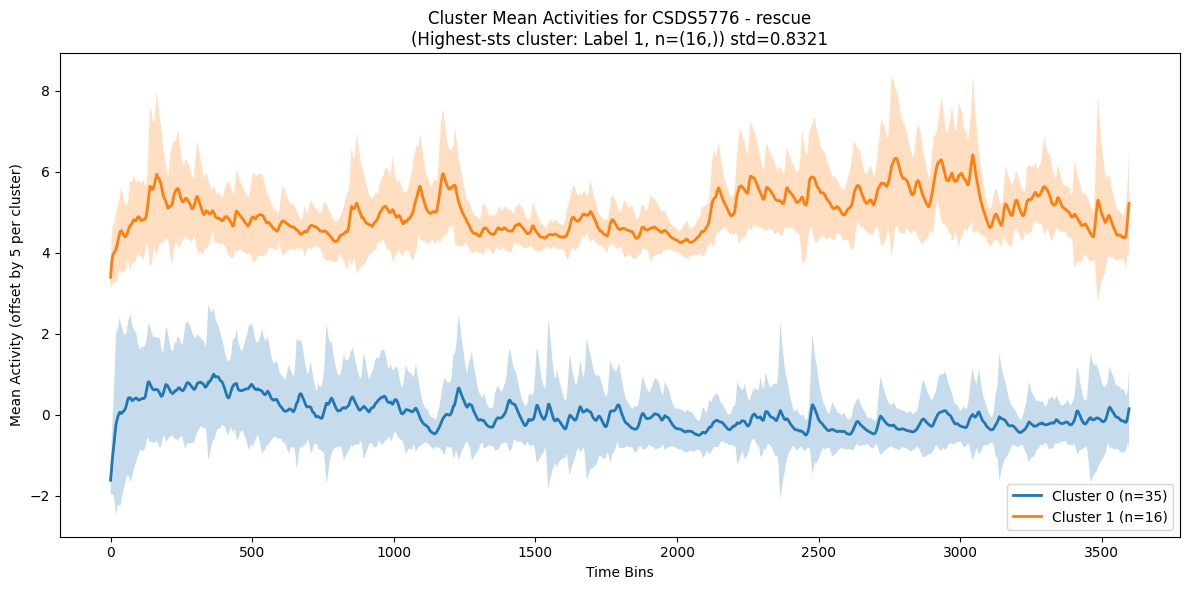

Processing CSDS5797 - rescue


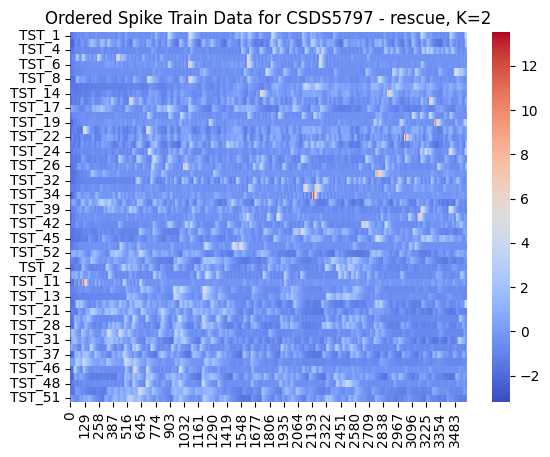

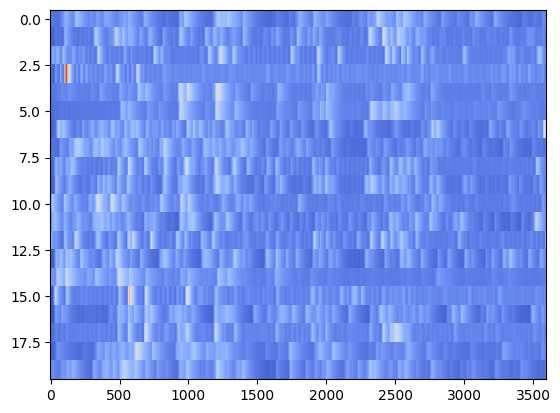

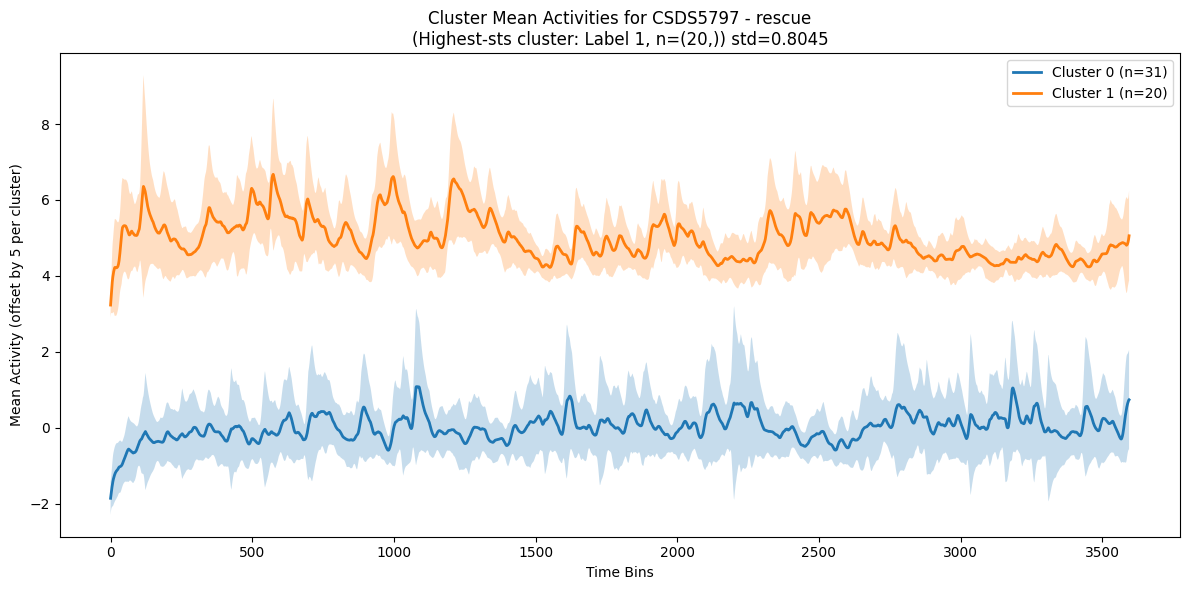

Processing CSDSQ26 - rescue


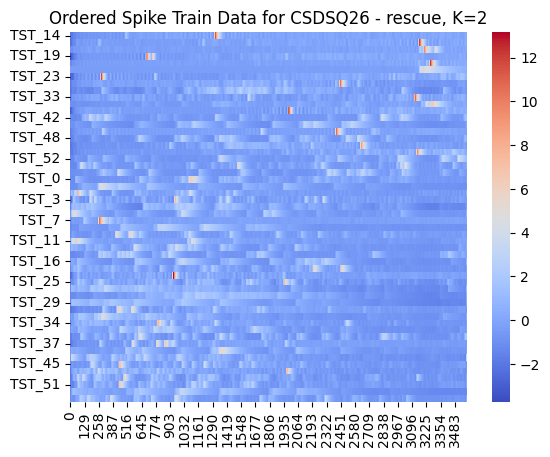

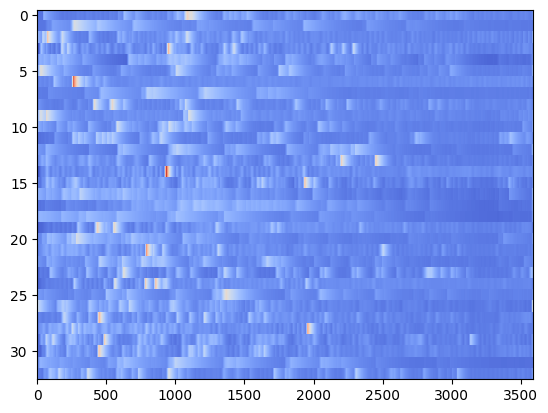

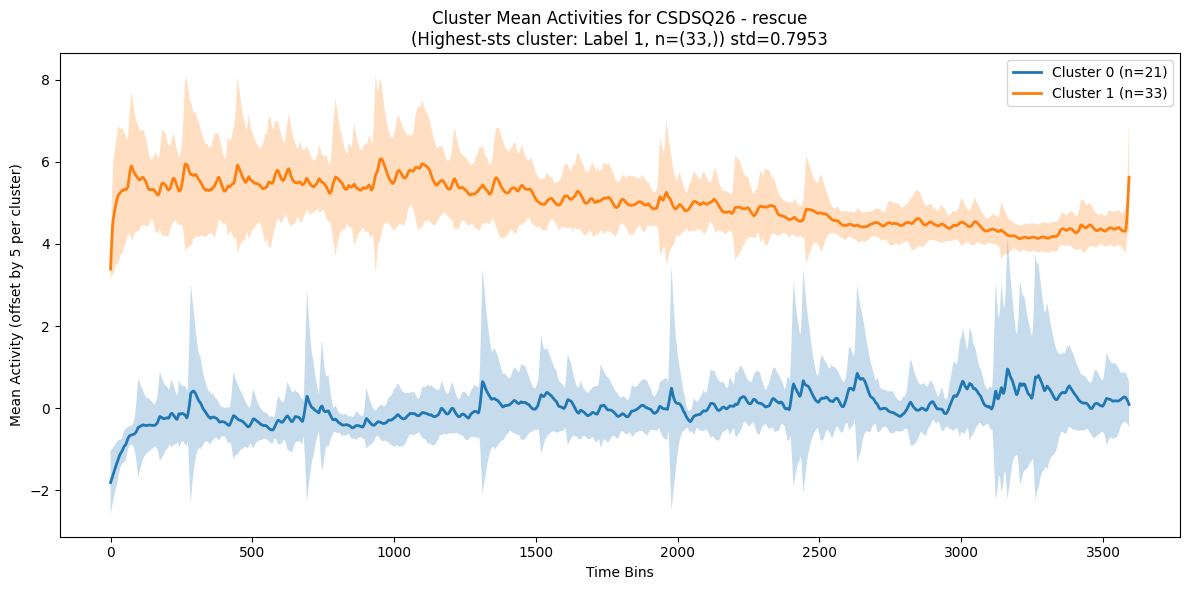

Processing LHQ30 - rescue


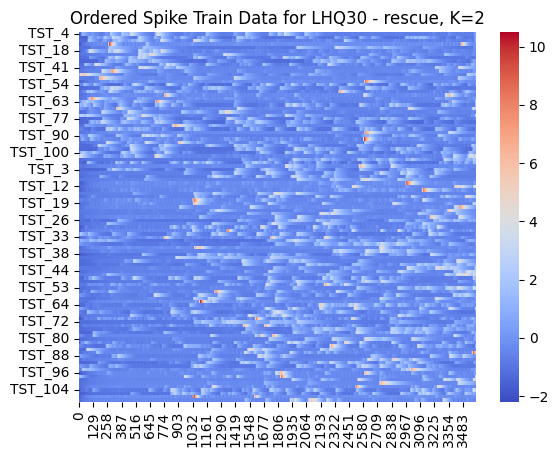

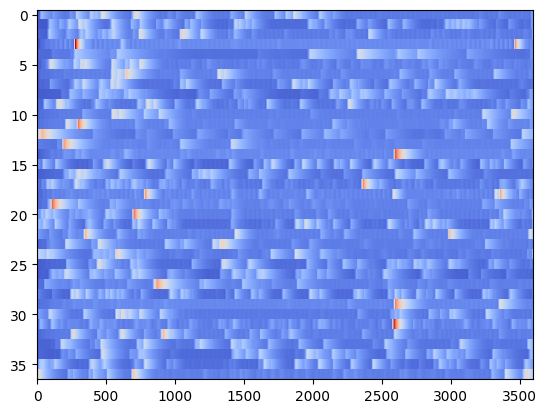

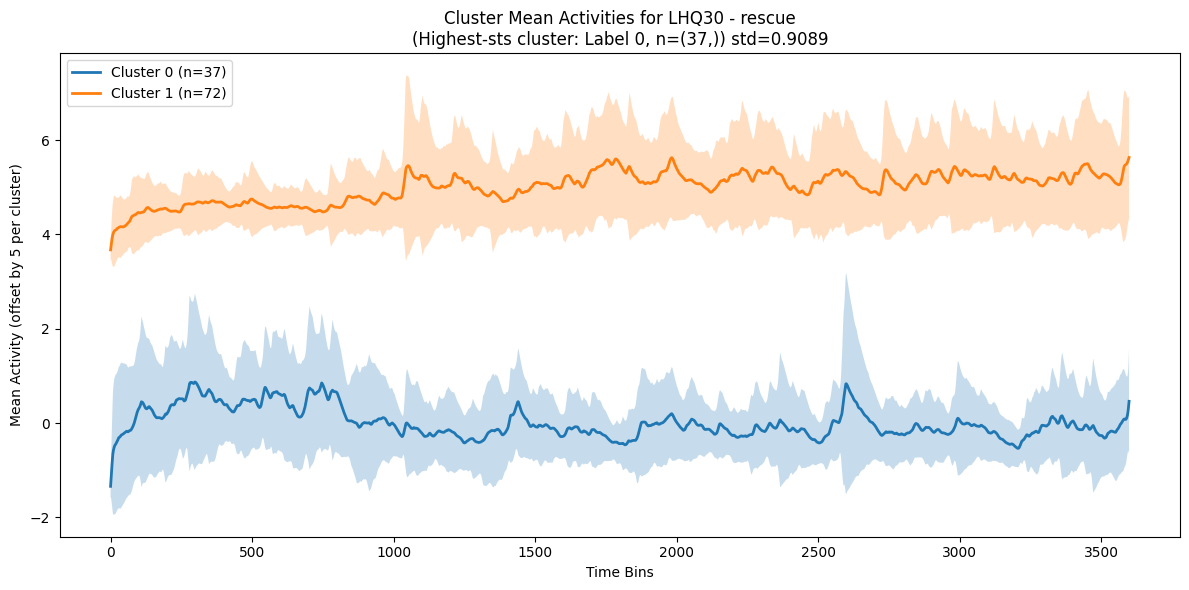

Processing LHQ50 - rescue


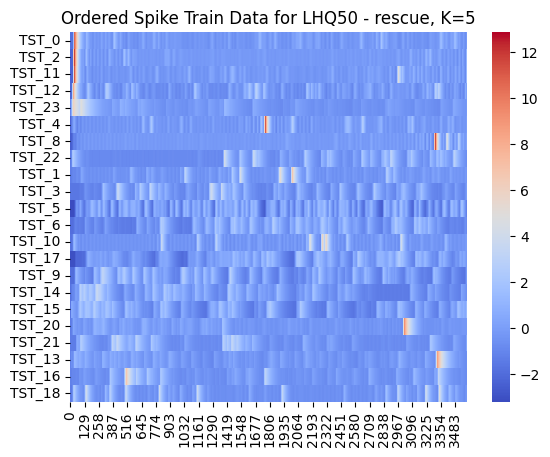

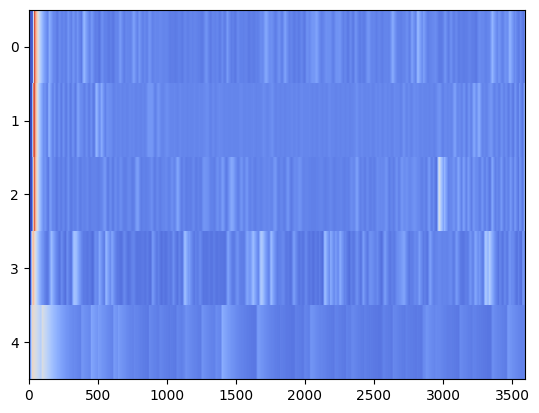

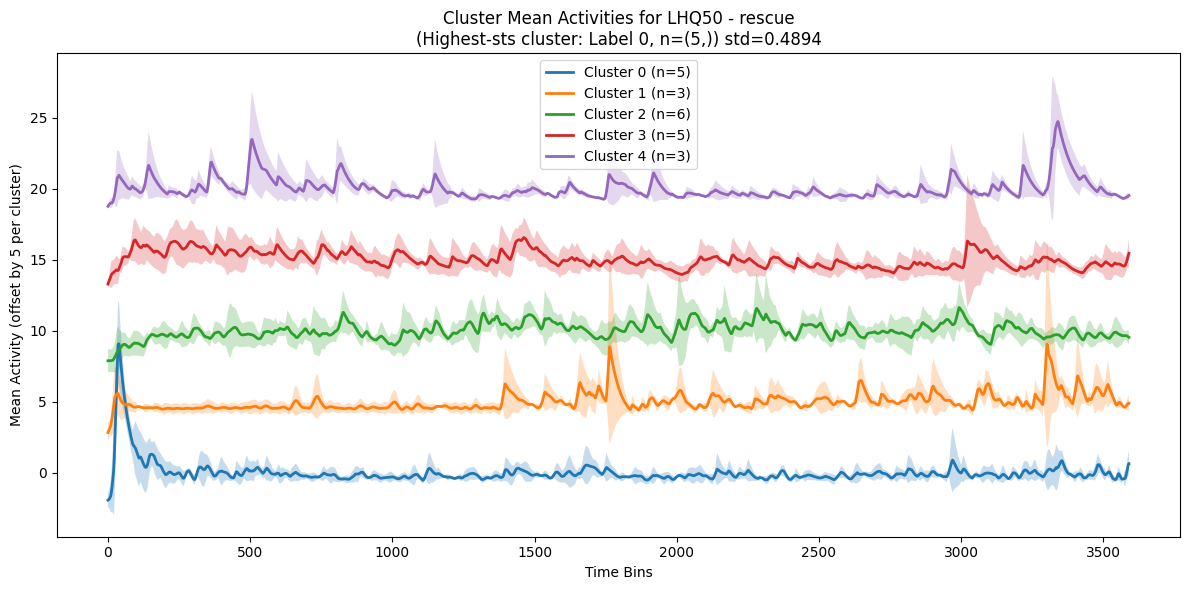

In [91]:
project_path = projectpath = 'G:\XJN_M2project'
model = 'test2'
group = 'depressed'
mice_ids = [
        #'CSDSQ26'  # line for testing
     "CSDS0126","LH0167","CSDS5776","CSDS5797","CSDSQ26","LHQ30","LHQ50" #   exclude = CSDS0087,CSDS0179,LH5798
    ]
conditions = ['pre', 'post', 'rescue']  # 'pre', 'post', 'rescue'
KNN_accuracy_df = pd.DataFrame(columns=['2D Accuracy','3D Accuracy'])
time_window = 4
half_win_bins = int(time_window )
# norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = 'RdBu_r'  # Red (positive) - White (0) - Blue (negative)
all_mice_MSTM_matrices = []
record_time = 1 #1s

Stat_savepath = os.path.join(projectpath, 'correlation_analysis', model, 'Analysis_Statistics')
std_df = pd.DataFrame()
result_list = []


for condition in conditions:
    std_condition = []
    for miceID in mice_ids:
        signal_path_TST_align = os.path.join(projectpath, 'signal_data', 'test2', condition, miceID, 'signal_save', f'{miceID}_{condition}_all_cell_table_TST.csv')
        mice_out = os.path.join(projectpath, 'signal_data', model,condition,miceID,'signal_save')
        if not os.path.exists(signal_path_TST_align):
            print(f"File not found: {signal_path_TST_align}, skipping {miceID}")
            continue

        print(f"Processing {miceID} - {condition}")
        TST_data = pd.read_csv(signal_path_TST_align)
        if 'Unnamed: 0' in TST_data.columns:
            TST_data = TST_data.drop(columns=['Unnamed: 0'])
        TST_data = TST_data.T
        plt.imshow(TST_data,aspect='auto',cmap='coolwarm')
        plt.title(f'Spike Train Data for {miceID} - {condition}')

    

        logging.info("Start KMeans clustering analysis...")
        logging.info("Calculate optimal K using Elbow Method...")
        K_range = range(2, 6)  # Test K from 2 to 8
        silhouette_scores = []
        for k in K_range:
            kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
            labels = kmeans.fit_predict(TST_data)
            score = silhouette_score(TST_data, labels, metric='euclidean')
            silhouette_scores.append(score)
        

        # Select the best K (maximum silhouette score)
        optimal_k = K_range[np.argmax(silhouette_scores)]
        logging.info(f"Optimal K (by Silhouette): {optimal_k}")

        # plt.figure(figsize=(8, 5))
        # plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
        # plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
        # plt.xlabel('Number of clusters (K)')
        # plt.ylabel('Average Silhouette Score')
        # plt.title('Silhouette Analysis for Optimal K')
        # plt.legend()
        # plt.grid(True, linestyle='--', alpha=0.6)
        # plt.show()

        logging.info(f"Optimal K (by max curvature): {optimal_k}")

        basic_partitions = []
        for k in range(max(2, optimal_k - 1), optimal_k + 2):
            labels = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(TST_data)
            basic_partitions.append(labels)

        # Step 2: Run KCC once using all basic partitions, with the target final cluster count K_final
        consensus_label = kcc_consensus(partitions=basic_partitions, K=optimal_k)

        # Step 3: Reorder data and visualize
        sorted_indices = np.argsort(consensus_label, kind='stable')
        sorted_labels = consensus_label[sorted_indices]
        TST_ordered = TST_data.iloc[sorted_indices]
        sns.heatmap(TST_ordered, cmap='coolwarm')
        plt.title(f'Ordered Spike Train Data for {miceID} - {condition}, K={len(np.unique(consensus_label))}')
        plt.show()
        TST_ordered_data = TST_ordered.copy()
        TST_ordered = pd.concat([TST_ordered, pd.Series(sorted_labels, name='Cluster Label', index=TST_ordered.index)], axis=1)
        TST_ordered.to_csv(os.path.join(mice_out, f'{miceID}_{condition}_KCC_ordered_TST.csv'), index=False)


        # Store statistics for each cluster
        cluster_stats = []
        means = []
        stds = []
        cluster_sts = []
        space_between = 5
        T = TST_ordered_data.shape[1]
        time_axis = np.arange(T) * 1  # Assume one unit per time bin

        unique_labels = np.unique(consensus_label)
        for label in unique_labels:
            # Locate this cluster in sorted_indices (i.e., row positions in TST_ordered)
            logging.debug(f"Visualizing cluster label: {label}")
            label_data = TST_ordered[TST_ordered['Cluster Label'] == label].drop(columns=['Cluster Label'])
            binary_data = (label_data > 2).astype(int)
            n_neurons = label_data.shape[0]
            # plt.imshow(binary_data, aspect='auto', cmap='grey_r')
            # plt.show()

            spike_trains = []  # or list
            for neuron in binary_data.index:
                # Get the binary sequence of this neuron
                spike_series = binary_data.loc[neuron].values  # shape: (T,)
                
                # Find all time indices where spikes occur
                spike_indices = np.where(spike_series == 1)[0]  # or spike_series.astype(bool)
                
                # Convert to actual time
                spike_times = time_axis[spike_indices]
                
                spike_trains.append(spike_times.tolist())  # or keep as np.array
            logging.debug(f"Computed spike trains for {len(spike_trains)} neurons.")
            logging.debug(f"Example spike train for neuron 0: {spike_trains[0]} ...")

            sts_matrix = compute_sts_matrix(spike_trains, dt=2)
            sts_average = mean_sts(sts_matrix)
            cluster_sts.append(sts_average)
            
            # Compute overall std (for plotting)
            mean_activity = label_data.mean()
            std_activity = label_data.std()  # Alternatively: np.sqrt(np.mean(std_activity**2))
            
            cluster_stats.append({
                'label': label,
                'n_neurons': n_neurons,
                'mean_activity': mean_activity,
                'std_activity': std_activity,
                'activity_peak': mean_activity.max(),
                'average_sts': sts_average,
                'overall_std': std_activity.mean()
            })
            means.append(mean_activity)
            stds.append(std_activity)

        # Find the cluster with the highest STS
            max_sts_cluster = max(cluster_stats, key=lambda x: x['average_sts'])
            logging.info(f"✅ Cluster with highest sts: Label = {max_sts_cluster['label']}")
        logging.info(f"    %neurons: {max_sts_cluster['n_neurons']/TST_ordered_data.shape[0]*100:.2f}%")
        logging.info(f"   Average std across time: {max_sts_cluster['average_sts']:.4f}")
        logging.info("Heatmap of the cluster with highest sts:")
        plt.imshow(TST_ordered[TST_ordered['Cluster Label'] == max_sts_cluster['label']].drop(columns=['Cluster Label']), aspect='auto', cmap='coolwarm',interpolation='none')
        plt.show()

        

        # Visualization
        plt.figure(figsize=(12, 6))
        for i, stat in enumerate(cluster_stats):
            mean_act = stat['mean_activity']
            std_act = stat['std_activity']
            offset = space_between * i
            
            plt.plot(mean_act + offset, label=f"Cluster {stat['label']} (n={stat['n_neurons']})", linewidth=2)
            plt.fill_between(
                range(len(mean_act)),
                (mean_act - std_act) + offset,
                (mean_act + std_act) + offset,
                alpha=0.25
            )

        plt.title(f'Cluster Mean Activities for {miceID} - {condition}\n'
                f'(Highest-sts cluster: Label {max_sts_cluster["label"]}, n={max_sts_cluster["n_neurons"],}) std={max_sts_cluster["overall_std"]:.4f}')
        plt.xlabel('Time Bins')
        plt.ylabel(f'Mean Activity (offset by {space_between} per cluster)')
        plt.legend()
        plt.tight_layout()
        plt.show()

        

        result_list.append({
            'MiceID': miceID,
            'Condition': condition,
            'Optimal_K': optimal_k,
            'Highest_STS_Cluster_Label': max_sts_cluster['label'],
            'Highest_STS_Cluster_Neuron_Count': max_sts_cluster['n_neurons'],
            'Highest_STS_Cluster_Neurons%': max_sts_cluster['n_neurons']/TST_data.shape[0],
            'Highest_STS_Cluster_Activity_Peak': max_sts_cluster['activity_peak'],
            'Highest_STS_Cluster_Avg_STD': np.round(max_sts_cluster['overall_std'],2),
            'Highest_STS_Cluster_Avg_STS': np.round(max_sts_cluster['average_sts'],2)
        })
        std_condition.append(np.round(std_activity.mean(),2))

    std_condition = np.array(std_condition)
    std_condition = pd.DataFrame(std_condition,columns=[f'{condition}_STDs'])
    std_df = pd.concat([std_df, pd.DataFrame(std_condition)], axis=1)

# Save results
result_list = pd.DataFrame(result_list)
result_df = pd.concat([result_list, std_df], axis=1)
result_savepath = os.path.join(Stat_savepath, f'{group}_KCC_Clustering_Results.csv')
result_df.to_csv(result_savepath, index=False)




In [89]:
basic_partitions

[array([3, 0, 3, 0, 1, 0, 0, 1, 2, 0, 3, 3, 1, 2, 2, 2, 0, 3, 2, 2, 1, 3]),
 array([4, 3, 4, 1, 3, 1, 1, 2, 2, 1, 4, 4, 2, 0, 0, 2, 1, 2, 0, 0, 4, 4]),
 array([2, 4, 2, 1, 5, 4, 4, 0, 1, 4, 2, 2, 3, 1, 1, 3, 4, 3, 5, 1, 0, 2])]

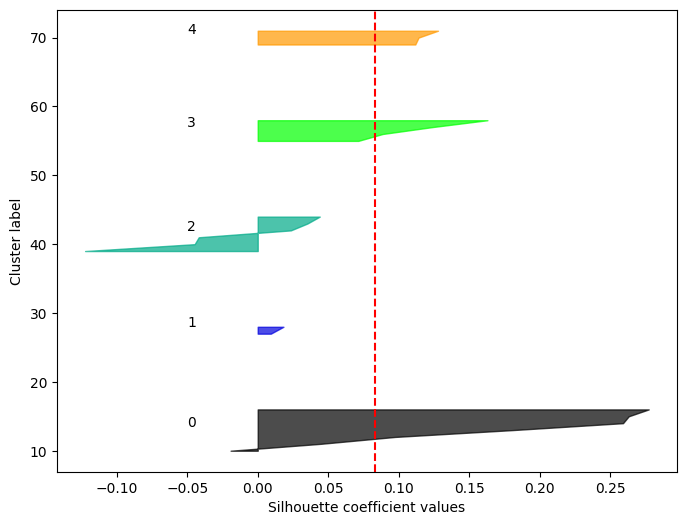

In [90]:
k = optimal_k
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
labels = KMeans(n_clusters=k).fit_predict(TST_data)
silhouette_avg = silhouette_score(TST_data, labels)
sample_silhouette_values = silhouette_samples(TST_data, labels)

y_lower = 10
for i in range(k):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / k)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_silhouette_values,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color="red", linestyle="--")
ax.set_xlabel('Silhouette coefficient values')
ax.set_ylabel('Cluster label')
plt.show()